<a href="https://colab.research.google.com/github/ymzprojects/UnsupervisedVehiclesDetection/blob/main/UnsupervisedVehiclesDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
from google.colab import drive
import pandas as pd
import cv2
import os
import numpy as np
import random
from google.colab.patches import cv2_imshow
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm
!pip install kneed -q
from kneed import KneeLocator
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Montage du Drive
drive.mount('/content/drive')

# 2. Chemins
zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/drive/MyDrive/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import zipfile
# import requests

# # 1. Configuration du lien Roboflow (PKLot Dataset)
# # Note : C'est le lien direct vers l'archive ZIP du dataset au format CSV/Voc
# url = "https://public.roboflow.com/ds/8u5M68sN0F?key=fXN9O2zVnS" # Lien généré pour PKLot v2
# dataset_zip = "pklot_dataset.zip"
# extract_path = "/content/pklot_data"

# # 2. Téléchargement du fichier
# print("Téléchargement du dataset PKLot...")
# response = requests.get(url, stream=True)
# total_size = int(response.headers.get('content-length', 0))

# with open(dataset_zip, "wb") as f, tqdm(
#     desc=dataset_zip,
#     total=total_size,
#     unit='iB',
#     unit_scale=True,
#     unit_divisor=1024,
# ) as bar:
#     for data in response.iter_content(chunk_size=1024):
#         size = f.write(data)
#         bar.update(size)

# # 3. Extraction du ZIP
# print("\nExtraction des fichiers...")
# if not os.path.exists(extract_path):
#     os.makedirs(extract_path)

# with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# # 4. Mise à jour des chemins pour la suite du notebook
# path_images = os.path.join(extract_path, "train") # Ou le dossier contenant les JPG
# ann_path = os.path.join(path_images, "_annotations.csv")

# print(f"✅ Dataset prêt dans : {path_images}")
# print(f"Fichier d'annotations : {ann_path}")

# # Nettoyage du fichier ZIP pour libérer de l'espace
# os.remove(dataset_zip)

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super(Autoencoder, self).__init__()
        # Encodeur : 128x128 -> 64x64 -> 32x32 -> 64 (Latent)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, latent_dim)
        )
        # Décodeur : 64 -> 32x32 -> 64x64 -> 128x128
        self.decoder_input = nn.Linear(latent_dim, 32 * 32 * 32)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        x = self.decoder_input(latent).view(-1, 32, 32, 32)
        x = self.decoder(x)
        return x, latent

In [ ]:
def display_global_otsu_comparison(raw_np, bin_np, filenames, labels_dict, n=3, label=True):
    for _ in range(n):
        # Sélection aléatoire
        idx = random.randint(0, len(filenames) - 1)
        name = filenames[idx]

        # 1. Préparation de l'image BRUTE (Avant)
        # On convertit en BGR pour pouvoir dessiner des labels en couleur si besoin
        before_img = cv2.cvtColor(raw_np[idx], cv2.COLOR_GRAY2BGR)

        # 2. Préparation de l'image BINARISÉE (Après)
        after_img = cv2.cvtColor(bin_np[idx], cv2.COLOR_GRAY2BGR)

        # 3. Ajout des labels si demandé
        if label and name in labels_dict:
            for obj in labels_dict[name]:
                x1, y1, x2, y2 = map(int, obj['bbox'])

                # Dessin sur les deux images pour comparer la précision
                for img in [before_img, after_img]:
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(img, obj['class'], (x1, y1 - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        # 4. Concaténation horizontale pour le "Avant / Après"
        comparison = np.hstack((before_img, after_img))

        print(f"--- Fichier : {name} (Gauche: Brut | Droite: Otsu Global) ---")
        cv2_imshow(cv2.resize(comparison, (1024, 512))) # Redimensionné pour que ça tienne sur l'écran

In [ ]:
def check_clusters(images_raw, labels, filenames, n_clusters):
    for cluster_id in range(n_clusters):
        print(f"\n--- Groupe Caméra {cluster_id} ---")
        indices = np.where(labels == cluster_id)[0]
        samples = random.sample(list(indices), min(len(indices), 3))

        row = []
        for idx in samples:
            img = images_raw[idx] # On utilise l'image d'origine pour voir le résultat
            img_res = cv2.resize(img, (256, 256))
            row.append(img_res)

        cv2_imshow(np.hstack(row))

In [ ]:
# 1. Configuration des chemins
path_images = '/content/drive/MyDrive/test'
ann_path = os.path.join(path_images, '_annotations.csv')

# 2. Chargement des labels (Dictionnaire)
df = pd.read_csv(ann_path)
labels = {}
for _, row in df.iterrows():
    name = row['filename']
    if name not in labels:
        labels[name] = []
    labels[name].append({
        'class': row['class'],
        'bbox': [row['xmin'], row['ymin'], row['xmax'], row['ymax']]
    })

# 3. Chargement des images brutes (Niveaux de gris) dans un tableau NumPy
raw_img_list = []
filenames = sorted([f for f in os.listdir(path_images) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

for f in filenames:
    img_bgr = cv2.imread(os.path.join(path_images, f))
    if img_bgr is not None:
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
        raw_img_list.append(gray)

# Conversion en un seul bloc NumPy [N, H, W]
all_raw_imgs = np.array(raw_img_list)
print(len(all_raw_imgs))

1241


In [ ]:
# Calcul de la luminosité moyenne pour chaque image (moyenne sur H et W)
mean_per_img = np.mean(all_raw_imgs, axis=(1, 2), keepdims=True)

# Calcul de la luminosité moyenne globale de tout le dataset
mean_global = np.mean(all_raw_imgs)

# Ajustement de toutes les images pour les aligner sur la moyenne globale
all_raw_imgs = all_raw_imgs - mean_per_img + mean_global

# Limitation des valeurs entre 0 et 255 et conversion en entier
all_raw_imgs = np.clip(all_raw_imgs, 0, 255).astype(np.uint8)

In [ ]:
# 4. Calcul du SEUIL GLOBAL d'Otsu
# On aplatit tout le dataset pour n'avoir qu'un vecteur de pixels
all_pixels = all_raw_imgs.flatten()

# OpenCV calcule le seuil optimal sur l'ensemble de la population de pixels
global_threshold, _ = cv2.threshold(all_pixels, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(f"✅ Seuil d'Otsu global calculé sur le dataset : {global_threshold}")

# 5. Application du seuil global sur l'ensemble du tableau NumPy
# On applique manuellement le seuil calculé pour obtenir le dataset binarisé
img_binarized = np.where(all_raw_imgs > global_threshold, 255, 0).astype(np.uint8)

✅ Seuil d'Otsu global calculé sur le dataset : 131.0


--- Fichier : 2013-03-14_09_10_55_jpg.rf.e7dae7dc63cf659b5c578d2a8871a661.jpg (Gauche: Brut | Droite: Otsu Global) ---


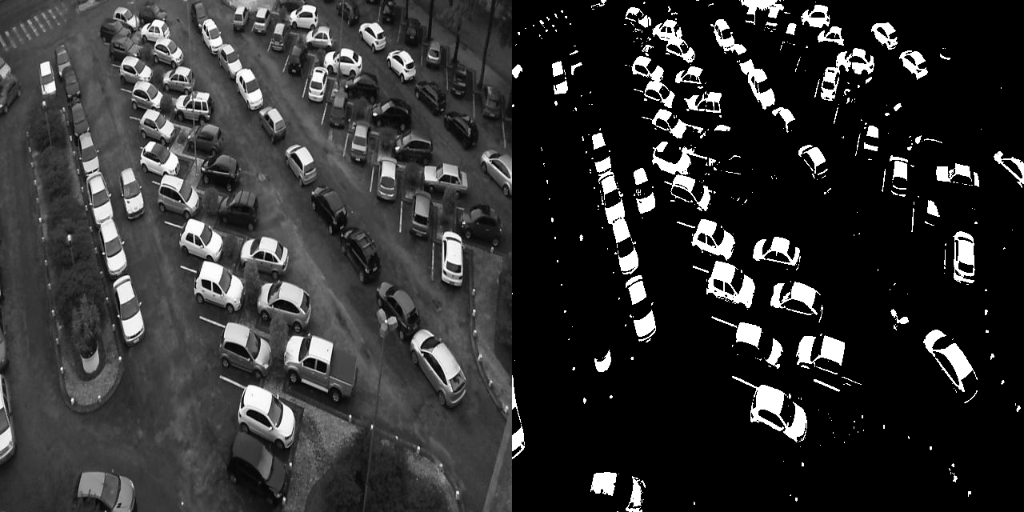

In [ ]:
# Utilisation :
# all_raw_imgs : ton numpy array d'images grises
# img_binarized : ton numpy array après le seuil global
display_global_otsu_comparison(all_raw_imgs, img_binarized, filenames, labels, n=1, label=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder(latent_dim=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [ ]:
# Redimensionnement global à 128x128
target_size = (128, 128)
img_resized = np.array([cv2.resize(im, target_size) for im in img_binarized])

# Préparation du dataset PyTorch [N, C, H, W]
X_tensor = torch.FloatTensor(img_resized).unsqueeze(1) / 255.0
dataset = TensorDataset(X_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
model.train()
epochs = 20
pbar_epochs = tqdm(range(epochs), desc="Entraînement")

for epoch in pbar_epochs:
    running_loss = 0.0
    for (data,) in loader:
        data = data.to(device)
        optimizer.zero_grad()
        output, _ = model(data)
        loss = criterion(output, data)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    pbar_epochs.set_postfix({'loss': f"{running_loss/len(loader):.4f}"})

print("✅ Phase 1 terminée : Modèle entraîné.")

Entraînement:   0%|          | 0/20 [00:00<?, ?it/s]

✅ Phase 1 terminée : Modèle entraîné.


In [ ]:
# A. Extraction des vecteurs latents (Inférence)
model.eval()
latents_list = []
eval_loader = DataLoader(TensorDataset(X_tensor), batch_size=32, shuffle=False)

with torch.no_grad():
    for (batch_x,) in tqdm(eval_loader, desc="Extraction des signatures"):
        _, latents = model(batch_x.to(device))
        latents_list.append(latents.cpu().numpy())

latents_np = np.concatenate(latents_list, axis=0)

# B. Normalisation (crucial pour la distance Euclidienne)
scaler = StandardScaler()
latents_scaled = scaler.fit_transform(latents_np)

Extraction des signatures:   0%|          | 0/39 [00:00<?, ?it/s]

📌 Nombre optimal de caméras détecté : 4


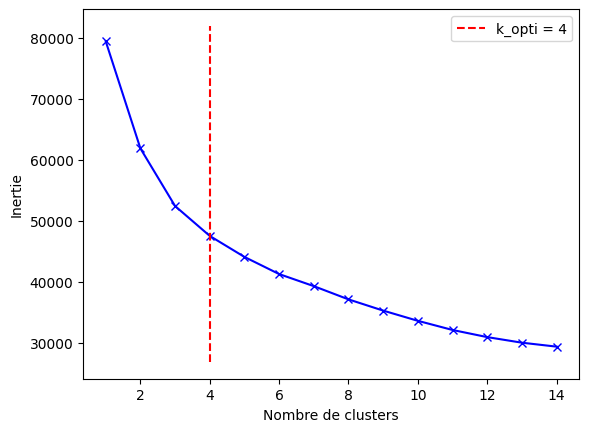

In [ ]:
# 1. Recherche du nombre optimal de clusters (Méthode du coude)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(latents_scaled)
    inertias.append(kmeans.inertia_)

# Détection automatique du coude
kn = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
k_opti = kn.knee

print(f"📌 Nombre optimal de caméras détecté : {k_opti}")

# 2. Clustering Hiérarchique avec le k optimal
cluster_model = AgglomerativeClustering(n_clusters=k_opti)
labels_cam = cluster_model.fit_predict(latents_scaled)

# Visualisation de la courbe pour vérification
plt.plot(k_range, inertias, 'bx-')
plt.vlines(k_opti, plt.ylim()[0], plt.ylim()[1], linestyles='--', colors='r', label=f'k_opti = {k_opti}')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.legend()
plt.show()

In [ ]:
# C. Clustering Hiérarchique (Agglomératif)
# Ajuste n_clusters au nombre de caméras supposé
cluster_model = AgglomerativeClustering(n_clusters=k_opti)
labels_cam = cluster_model.fit_predict(latents_scaled)

print(f"✅ Phase 2 terminée : {k_opti} groupes de caméras identifiés.")

✅ Phase 2 terminée : 4 groupes de caméras identifiés.



--- Groupe Caméra 0 ---


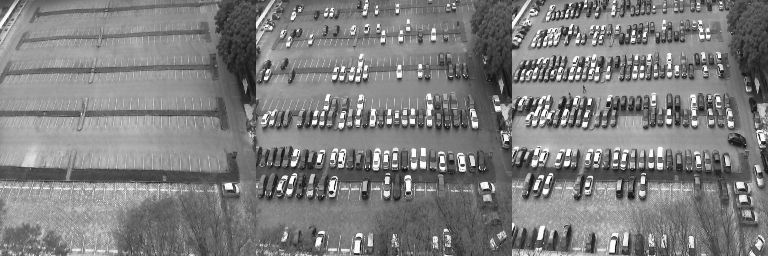


--- Groupe Caméra 1 ---


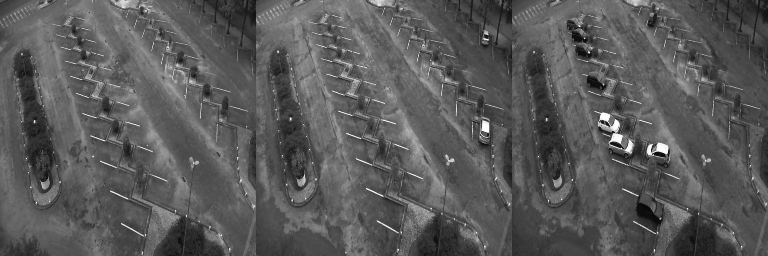


--- Groupe Caméra 2 ---


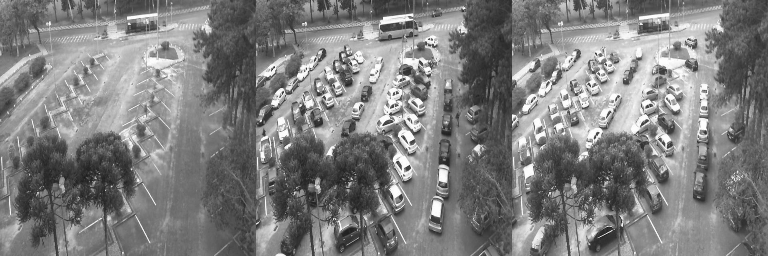


--- Groupe Caméra 3 ---


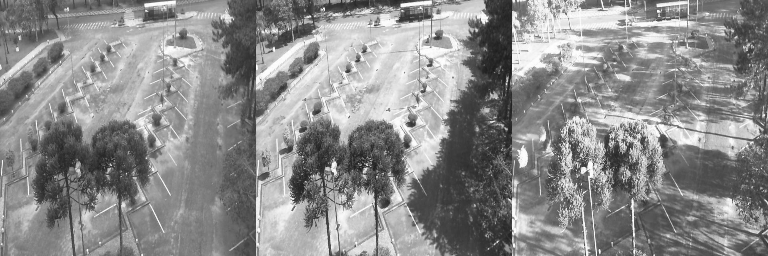

In [ ]:
# images_raw doit être ton numpy d'origine (img_binarized ou all_raw_imgs)
check_clusters(all_raw_imgs, labels_cam, filenames, k_opti)

In [ ]:
def detect_vehicles_in_cluster(cluster_images, min_area=100):
    median_background = np.median(cluster_images, axis=0).astype(np.uint8)
    kernel = np.ones((5, 5), np.uint8)
    results = []

    for img in cluster_images:
        diff = cv2.absdiff(img, median_background)

        # Application du seuillage d'Otsu sur l'image de différence
        _, thresh = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Nettoyage par ouverture (érosion puis dilatation) pour supprimer le bruit
        cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

        # Ajout d'une fermeture optionnelle pour consolider les formes des véhicules
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(img.shape) == 2:
            display_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        else:
            display_img = img.copy()

        boxes = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area > min_area:
                x, y, w, h = cv2.boundingRect(cnt)
                boxes.append((x, y, w, h))
                cv2.rectangle(display_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

        results.append({
            'image': display_img,
            'boxes': boxes,
            'mask': cleaned
        })

    return median_background, results

def show_detections(results_list, num_samples=3):
    positive_results = [res for res in results_list if len(res['boxes']) > 0]
    print(f"Véhicules trouvés dans {len(positive_results)} images sur {len(results_list)}")

    if not positive_results:
        print("Rien à afficher.")
        return

    samples = random.sample(positive_results, min(num_samples, len(positive_results)))

    for res in samples:
        img_box = res['image']
        mask = res['mask']

        mask_bgr = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

        h, w = img_box.shape[:2]
        scale = 300 / h
        dim = (int(w * scale), int(h * scale))

        img_res = cv2.resize(img_box, dim)
        mask_res = cv2.resize(mask_bgr, dim)

        combined = np.hstack((img_res, mask_res))
        cv2_imshow(combined)

In [ ]:
median, res = detect_vehicles_in_cluster(all_raw_imgs[labels_cam==2])

Véhicules trouvés dans 151 images sur 151


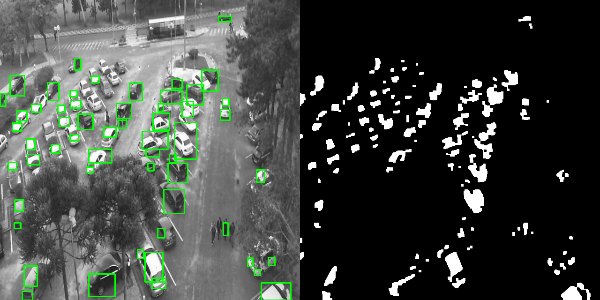

In [ ]:
show_detections(res, num_samples=1)